In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path = "D:\Projects\Banking-credit-risk- analysis\data\LC_loans_granting_model_dataset.csv"
df = pd.read_csv(file_path, low_memory=False)
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\dipro\AppData\Local\Temp\ipykernel_22436\319159259.py:1: SyntaxWarning: invalid escape sequence '\P'
  file_path = "D:\Projects\Banking-credit-risk- analysis\data\LC_loans_granting_model_dataset.csv"


,id,issue_d,revenue,dti_n,loan_amnt,fico_n,experience_c,emp_length,purpose,home_ownership_n,addr_state,zip_code,Default,title,desc
0,68407277,Dec-2015,55000.0,5.91,3600,677.0,1,10+ years,debt_consolidation,MORTGAGE,PA,190xx,0,Debt consolidation,NaN
1,68355089,Dec-2015,65000.0,16.06,24700,717.0,1,10+ years,small_business,MORTGAGE,SD,577xx,0,Business,NaN
2,68341763,Dec-2015,71000.0,13.85,20000,697.0,1,10+ years,home_improvement,MORTGAGE,IL,605xx,0,NaN,NaN
3,68476807,Dec-2015,104433.0,25.37,10400,697.0,1,3 years,major_purchase,MORTGAGE,PA,174xx,0,Major purchase,NaN
4,68426831,Dec-2015,34000.0,10.20,11950,692.0,1,4 years,debt_consolidation,RENT,GA,300xx,0,Debt consolidation,NaN


In [7]:
df.shape

(1347681, 15)

In [8]:
df.columns

Index(['id', 'issue_d', 'revenue', 'dti_n', 'loan_amnt', 'fico_n',
       'experience_c', 'emp_length', 'purpose', 'home_ownership_n',
       'addr_state', 'zip_code', 'Default', 'title', 'desc'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1347681 entries, 0 to 1347680
Data columns (total 15 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   id                1347681 non-null  int64  
 1   issue_d           1347681 non-null  str    
 2   revenue           1347681 non-null  float64
 3   dti_n             1347681 non-null  float64
 4   loan_amnt         1347681 non-null  int64  
 5   fico_n            1347681 non-null  float64
 6   experience_c      1347681 non-null  int64  
 7   emp_length        1347681 non-null  str    
 8   purpose           1347681 non-null  str    
 9   home_ownership_n  1347681 non-null  str    
 10  addr_state        1347681 non-null  str    
 11  zip_code          1347680 non-null  str    
 12  Default           1347681 non-null  int64  
 13  title             1331024 non-null  str    
 14  desc              119099 non-null   str    
dtypes: float64(3), int64(4), str(8)
memory usage: 154.2 MB


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1347681.0,5.621359e+07,3.839501e+07,54734.0,19706506.00,57664225.00,84495046.00,145636374.0
revenue,1347681.0,7.736968e+04,7.036299e+04,1896.0,46600.00,65000.00,92000.00,10999200.0
dti_n,1347681.0,1.829909e+01,1.115214e+01,0.0,11.82,17.63,24.07,999.0
loan_amnt,1347681.0,1.440823e+04,8.715347e+03,500.0,7975.00,12000.00,20000.00,40000.0
fico_n,1347681.0,6.981589e+02,3.184872e+01,612.0,672.00,692.00,712.00,847.5
experience_c,1347681.0,9.999814e-01,4.306977e-03,0.0,1.00,1.00,1.00,1.0
Default,1347681.0,1.997869e-01,3.998402e-01,0.0,0.00,0.00,0.00,1.0


In [14]:
missing = pd.DataFrame({
    "missing_count":df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2)
})
missing.sort_values("missing_percentage", ascending=False)

,missing_count,missing_percentage
desc,1228582,91.16
title,16657,1.24
id,0,0.00
dti_n,0,0.00
loan_amnt,0,0.00
issue_d,0,0.00
revenue,0,0.00
experience_c,0,0.00
fico_n,0,0.00
emp_length,0,0.00


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["id"].duplicated().sum()

np.int64(0)

In [17]:
df["id"].nunique()

1347681

In [18]:
print("Default value counts:")
print(df["Default"].value_counts())

print("\nDefault percentage:")
print((df["Default"].value_counts(normalize=True) * 100).round(2))

Default value counts:
Default
0    1078432
1     269249
Name: count, dtype: int64

Default percentage:
Default
0    80.02
1    19.98
Name: proportion, dtype: float64


In [33]:
print("maximum DTI : ", df['dti_n'].max())
print("number of DTI = 999 is : ", (df["dti_n"] == 999).sum())
percentage = ((df["dti_n"] == 999).mean() * 100).round(4)
print(f"percentage of dti_n = 999 is: {percentage}")

maximum DTI :  999.0
number of DTI = 999 is :  38
percentage of dti_n = 999 is: 0.0028


In [35]:
df.columns
df.head()

,id,issue_d,revenue,dti_n,loan_amnt,fico_n,experience_c,emp_length,purpose,home_ownership_n,addr_state,zip_code,Default,title,desc
0,68407277,Dec-2015,55000.0,5.91,3600,677.0,1,10+ years,debt_consolidation,MORTGAGE,PA,190xx,0,Debt consolidation,NaN
1,68355089,Dec-2015,65000.0,16.06,24700,717.0,1,10+ years,small_business,MORTGAGE,SD,577xx,0,Business,NaN
2,68341763,Dec-2015,71000.0,13.85,20000,697.0,1,10+ years,home_improvement,MORTGAGE,IL,605xx,0,NaN,NaN
3,68476807,Dec-2015,104433.0,25.37,10400,697.0,1,3 years,major_purchase,MORTGAGE,PA,174xx,0,Major purchase,NaN
4,68426831,Dec-2015,34000.0,10.20,11950,692.0,1,4 years,debt_consolidation,RENT,GA,300xx,0,Debt consolidation,NaN


In [36]:
categorical_columns = [
    "purpose",
    "emp_length",
    "home_ownership_n"
]

for col in categorical_columns:
    print("\n==============================")
    print(col)
    print("==============================")
    print(df[col].value_counts(dropna=False))


purpose
purpose
debt_consolidation    781206
credit_card           295551
home_improvement       87684
other                  78263
major_purchase         29543
medical                15606
small_business         15575
car                    14647
moving                  9520
vacation                9083
house                   7294
wedding                 2350
renewable_energy         936
educational              423
Name: count, dtype: int64

emp_length
emp_length
10+ years    442667
2 years      122091
< 1 year     108517
3 years      107862
1 year        88841
5 years       84326
4 years       80761
NI            78188
6 years       62877
8 years       60808
7 years       59724
9 years       51019
Name: count, dtype: int64

home_ownership_n
home_ownership_n
MORTGAGE    666594
RENT        535585
OWN         144985
OTHER          517
Name: count, dtype: int64


In [38]:
print("PURPOSE CATEGORIES:", df["purpose"].nunique())
print("EMPLOYMENT CATEGORIES:", df["emp_length"].nunique())
print("HOME OWNERSHIP CATEGORIES:", df["home_ownership_n"].nunique())

print("\nHome Ownership:")
print(df["home_ownership_n"].value_counts())

PURPOSE CATEGORIES: 14
EMPLOYMENT CATEGORIES: 12
HOME OWNERSHIP CATEGORIES: 4

Home Ownership:
home_ownership_n
MORTGAGE    666594
RENT        535585
OWN         144985
OTHER          517
Name: count, dtype: int64


In [39]:
print("Default distribution:")
print(df["Default"].value_counts())

print("\nDefault percentage:")
print((df["Default"].value_counts(normalize=True) * 100).round(2))

print("\nDTI:")
print("Maximum:", df["dti_n"].max())
print("Number of 999:", (df["dti_n"] == 999).sum())
print("Percentage of 999:", round((df["dti_n"] == 999).mean() * 100, 4))

Default distribution:
Default
0    1078432
1     269249
Name: count, dtype: int64

Default percentage:
Default
0    80.02
1    19.98
Name: proportion, dtype: float64

DTI:
Maximum: 999.0
Number of 999: 38
Percentage of 999: 0.0028


In [40]:
print("Unique Titles : ", df['title'].nunique())
print("Missing Title : ", df["title"].isna().sum())
print("\nMost common titles : ")
print(df["title"].value_counts().head(15))

Unique Titles :  61451
Missing Title :  16657

Most common titles : 
title
Debt consolidation         661113
Credit card refinancing    249854
Home improvement            75104
Other                       66746
Major purchase              24040
Debt Consolidation          16417
Medical expenses            13572
Business                    11769
Car financing               11220
Vacation                     8059
Moving and relocation        7938
Home buying                  5894
Consolidation                5678
debt consolidation           5084
Debt Consolidation Loan      3867
Name: count, dtype: int64


**1st Decision: conclude Title and desc**


In [ ]:
df_clean = df.drop(columns=["title", "desc"]).copy()


In [45]:
df_clean.head()

,id,issue_d,revenue,dti_n,loan_amnt,fico_n,experience_c,emp_length,purpose,home_ownership_n,addr_state,zip_code,Default
0,68407277,Dec-2015,55000.0,5.91,3600,677.0,1,10+ years,debt_consolidation,MORTGAGE,PA,190xx,0
1,68355089,Dec-2015,65000.0,16.06,24700,717.0,1,10+ years,small_business,MORTGAGE,SD,577xx,0
2,68341763,Dec-2015,71000.0,13.85,20000,697.0,1,10+ years,home_improvement,MORTGAGE,IL,605xx,0
3,68476807,Dec-2015,104433.0,25.37,10400,697.0,1,3 years,major_purchase,MORTGAGE,PA,174xx,0
4,68426831,Dec-2015,34000.0,10.20,11950,692.0,1,4 years,debt_consolidation,RENT,GA,300xx,0


In [47]:
df_clean[df_clean["dti_n"] == 999][
    ["id", "revenue", "dti_n", "loan_amnt", "fico_n", "Default"]
]

,id,revenue,dti_n,loan_amnt,fico_n,Default
7767,67405134,62151.0,999.0,6550,672.0,0
381305,129679050,78800.0,999.0,8000,687.0,0
386273,127916653,66633.0,999.0,10250,712.0,0
394079,126388240,126665.0,999.0,14225,752.0,0
398115,120060219,58800.0,999.0,15000,717.0,0
398172,119987558,153000.0,999.0,26000,762.0,0
402650,119333994,76000.0,999.0,21000,692.0,0
404149,115381037,138100.0,999.0,10000,722.0,0
411443,117560607,160300.0,999.0,35000,672.0,0
417509,116709237,145600.0,999.0,35000,677.0,1


In [49]:
df_clean["dti_n"] = df_clean["dti_n"].replace(999, np.nan)

In [50]:
max = df_clean["dti_n"].max()
max

np.float64(991.57)

In [51]:
print("DTI missing values:", df_clean["dti_n"].isna().sum())
print("Maximum DTI:", df_clean["dti_n"].max())

DTI missing values: 38
Maximum DTI: 991.57


In [52]:
print("DTI > 100: ", (df_clean["dti_n"] > 100).sum())

print("\nHighest DTI values: ")
print(
    df_clean["dti_n"].dropna().sort_values(ascending=False).head(20)
)

DTI > 100:  495

Highest DTI values: 
431841     991.57
975682     886.77
415119     879.55
1281149    831.97
479076     822.00
469909     818.10
1271360    797.10
905214     771.31
425255     765.76
1279419    762.50
398872     751.22
500680     747.13
1256586    740.96
910208     697.04
425888     674.70
64854      672.52
898263     669.23
512901     654.77
1263541    651.44
1307221    641.36
Name: dti_n, dtype: float64


In [53]:
dti_percentiles = df_clean["dti_n"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999, 1.00]
)

dti_percentiles

0.500     17.63000
0.750     24.07000
0.900     29.78000
0.950     32.99000
0.990     38.47580
0.995     40.05000
0.999     65.24716
1.000    991.57000
Name: dti_n, dtype: float64

In [54]:
print("Data Type: ", df_clean["issue_d"].dtype)
df_clean["issue_d"].head(10)

Data Type:  str


0    Dec-2015
1    Dec-2015
2    Dec-2015
3    Dec-2015
4    Dec-2015
5    Dec-2015
6    Dec-2015
7    Dec-2015
8    Dec-2015
9    Dec-2015
Name: issue_d, dtype: str

In [60]:
print("Unique Dates: ", df_clean["issue_d"].nunique())
print("\nDate values:", df_clean["issue_d"].unique()[:20])

Unique Dates:  139

Date values: <StringArray>
['Dec-2015', 'Nov-2015', 'Oct-2015', 'Sep-2015', 'Aug-2015', 'Jul-2015',
 'Jun-2015', 'May-2015', 'Apr-2015', 'Mar-2015', 'Feb-2015', 'Jan-2015',
 'Mar-2018', 'Feb-2018', 'Jan-2018', 'Sep-2017', 'Aug-2017', 'Jul-2017',
 'Jun-2016', 'May-2016']
Length: 20, dtype: str


In [67]:
df_clean["issue_date"] = pd.to_datetime(
    df_clean["issue_d"],
    format="%b-%Y"
)

In [68]:
print(df_clean[["issue_d", "issue_date"]].head())

print("\nNew data type:")
print(df_clean["issue_date"].dtype)

     issue_d issue_date
0 2015-12-01 2015-12-01
1 2015-12-01 2015-12-01
2 2015-12-01 2015-12-01
3 2015-12-01 2015-12-01
4 2015-12-01 2015-12-01

New data type:
datetime64[us]


In [69]:
df_clean["issue_d"] = df["issue_d"].copy()

In [70]:
df_clean["issue_date"] = pd.to_datetime(
    df_clean["issue_d"],
    format="%b-%Y"
)

print(df_clean[["issue_d", "issue_date"]].head())
print("\nData type:", df_clean["issue_date"].dtype)

    issue_d issue_date
0  Dec-2015 2015-12-01
1  Dec-2015 2015-12-01
2  Dec-2015 2015-12-01
3  Dec-2015 2015-12-01
4  Dec-2015 2015-12-01

Data type: datetime64[us]


In [71]:
df_clean["issue_year"] = df_clean["issue_date"].dt.year
df_clean["issue_month"] = df_clean["issue_date"].dt.month

print(df_clean[["issue_date", "issue_year", "issue_month"]].head())

  issue_date  issue_year  issue_month
0 2015-12-01        2015           12
1 2015-12-01        2015           12
2 2015-12-01        2015           12
3 2015-12-01        2015           12
4 2015-12-01        2015           12


In [72]:
print("Years:", sorted(df_clean["issue_year"].unique()))
print("Number of years:", df_clean["issue_year"].nunique())

Years: [np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]
Number of years: 12


**Checking Numerical veriables for data quality**

In [75]:
numeric_cols = ["revenue", "loan_amnt", "fico_n"]

for col in numeric_cols:
    print("\n--------------------")
    print(col)
    print("=======================")
    print(
        df_clean[col].quantile(
            [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.05, 0.99, 1.00]
        )
    )


--------------------
revenue
0.00        1896.0
0.01       19000.0
0.05       28329.0
0.25       46600.0
0.50       65000.0
0.75       92000.0
0.05       28329.0
0.99      260000.0
1.00    10999200.0
Name: revenue, dtype: float64

--------------------
loan_amnt
0.00      500.0
0.01     1500.0
0.05     3200.0
0.25     7975.0
0.50    12000.0
0.75    20000.0
0.05     3200.0
0.99    35000.0
1.00    40000.0
Name: loan_amnt, dtype: float64

--------------------
fico_n
0.00    612.0
0.01    662.0
0.05    662.0
0.25    672.0
0.50    692.0
0.75    712.0
0.05    662.0
0.99    802.0
1.00    847.5
Name: fico_n, dtype: float64


In [76]:
print("Revenue <= 0:", (df_clean["revenue"] <= 0).sum())
print("Loan amount <= 0:", (df_clean["loan_amnt"] <= 0).sum())
print("FICO <= 0:", (df_clean["fico_n"] <= 0).sum())

print("\nFICO minimum:", df_clean["fico_n"].min())
print("FICO maximum:", df_clean["fico_n"].max())

Revenue <= 0: 0
Loan amount <= 0: 0
FICO <= 0: 0

FICO minimum: 612.0
FICO maximum: 847.5


**Lets see if the credit score have a relationship with loan default**

In [77]:
df_clean["fico_group"] = pd.cut(
    df_clean["fico_n"],
    bins=[0, 649, 699, 749, float("inf")],
    labels=["below 650", "650-699", "700-749","750+"]
)

In [79]:
fico_default = (
    df_clean.groupby("fico_group", observed=False)["Default"]
    .agg(["count", "mean"])
)

fico_default["default_rate_%"] = (
    fico_default["mean"] * 100
).round(2)

print(fico_default)

             count      mean  default_rate_%
fico_group                                  
below 650      231  0.320346           32.03
650-699     822284  0.236029           23.60
700-749     418569  0.156782           15.68
750+        106597  0.088821            8.88


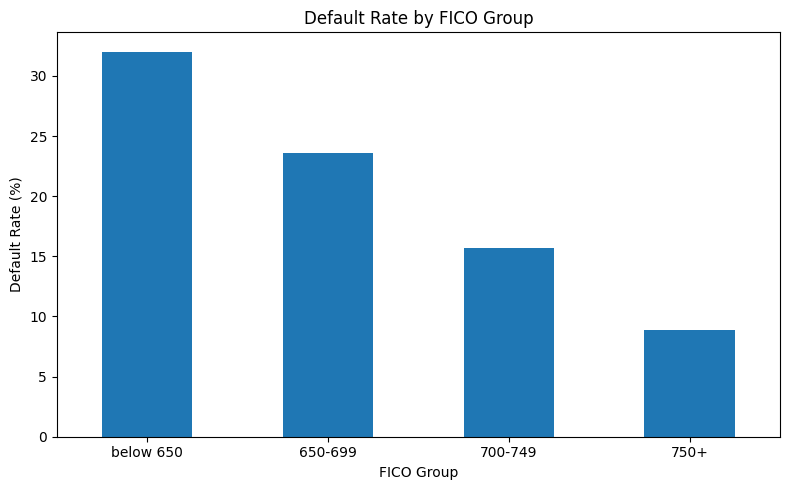

In [82]:
fico_default["default_rate_%"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Default Rate by FICO Group")
plt.xlabel("FICO Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Lets check debt-to-income have relationship with default risk**

In [83]:
df_clean["dti_group"] = pd.cut(
    df_clean["dti_n"],
    bins= [0, 10, 20, 30, 40, float("inf")],
    labels=["<10", "10-20", "20-30","30-40","40+"],
    right=False
)

In [84]:
dti_default = (
    df_clean
    .groupby("dti_group", observed=False)["Default"]
    .agg(["count", "mean"])
)

dti_default["default_rate_%"] = (
    dti_default["mean"] * 100
).round(2)

dti_default

,count,mean,default_rate_%
dti_group,,,
<10,245174,0.148417,14.84
10-20,563230,0.178465,17.85
20-30,410172,0.230747,23.07
30-40,122297,0.291176,29.12
40+,6770,0.307090,30.71


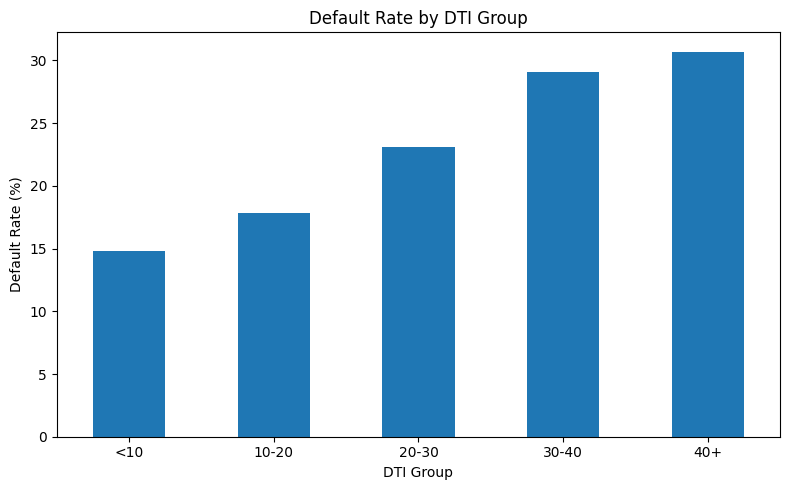

In [85]:
dti_default["default_rate_%"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Default Rate by DTI Group")
plt.xlabel("DTI Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Now lets see the loan amount vs Default**

In [86]:
df_clean["loan_group"] = pd.cut(
    df_clean["loan_amnt"],
    bins=[0, 5000, 10000, 20000, 30000, float("inf")],
    labels=["<5k", "5k-10k", "10k-20k", "20k-30k","30k+"],
    right=False
)

In [87]:
loan_default = (
    df_clean
    .groupby("loan_group", observed=False)["Default"]
    .agg(["count", "mean"])
)

loan_default["default_rate_%"] = (
    loan_default["mean"] * 100
).round(2)

loan_default

,count,mean,default_rate_%
loan_group,,,
<5k,133847,0.155229,15.52
5k-10k,323710,0.167088,16.71
10k-20k,527792,0.210994,21.10
20k-30k,252203,0.223415,22.34
30k+,110129,0.242234,24.22


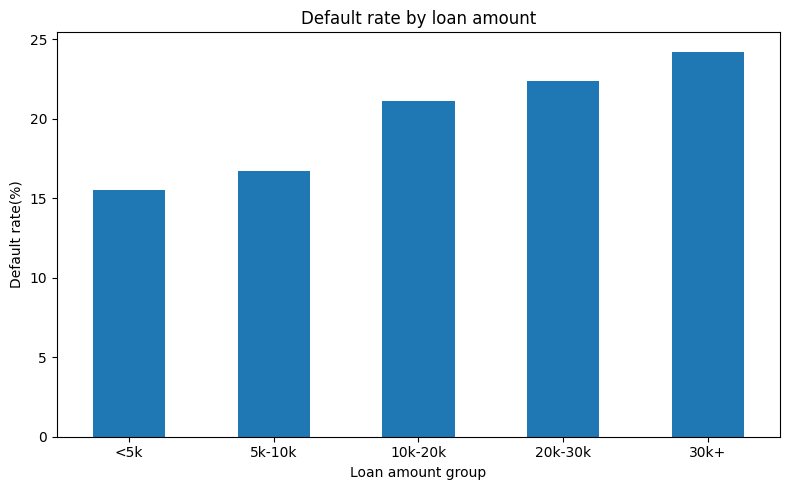

In [88]:
loan_default["default_rate_%"].plot(kind="bar", figsize=(8,5))
plt.title("Default rate by loan amount")
plt.xlabel("Loan amount group")
plt.ylabel("Default rate(%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Lets check Loan Purpose**

In [89]:
purpose_default = (
    df_clean
    .groupby("purpose")["Default"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

purpose_default["default_rate_%"] = (
    purpose_default["mean"] * 100
).round(2)

purpose_default

,count,mean,default_rate_%
purpose,,,
small_business,15575,0.298555,29.86
renewable_energy,936,0.237179,23.72
moving,9520,0.234139,23.41
house,7294,0.219084,21.91
medical,15606,0.218442,21.84
debt_consolidation,781206,0.211542,21.15
other,78263,0.210840,21.08
educational,423,0.208038,20.80
vacation,9083,0.191897,19.19


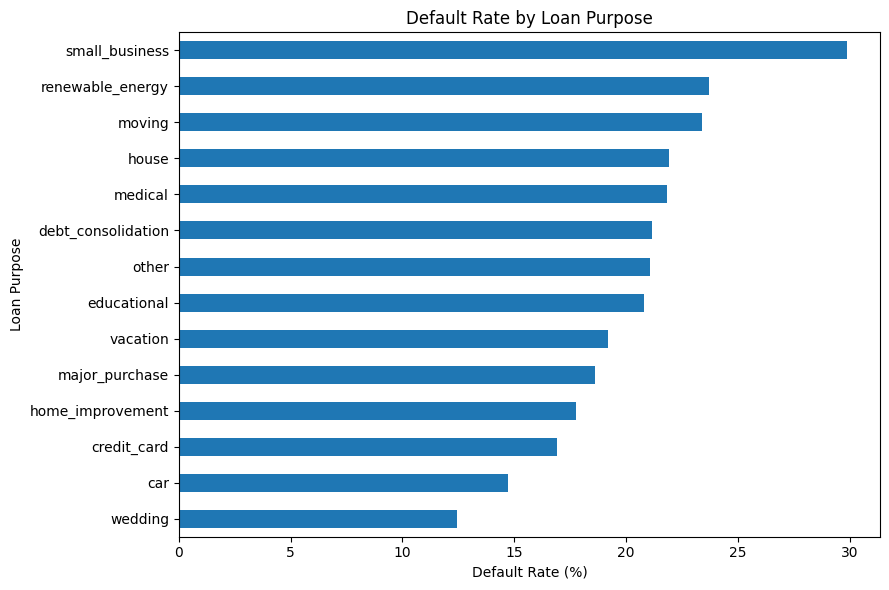

In [ ]:
purpose_default["default_rate_%"].sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Default Rate (%)")
plt.ylabel("Loan Purpose")
plt.tight_layout()
plt.show()

**lets analysis home ownership vs default**

In [93]:
home_default = (
    df_clean
    .groupby("home_ownership_n")["Default"]
    .agg(["count", "mean"])
)

home_default["default_rate_%"] = (
    home_default["mean"] * 100
).round(2)

home_default.sort_values("default_rate_%", ascending=False)

,count,mean,default_rate_%
home_ownership_n,,,
RENT,535585,0.232284,23.23
OWN,144985,0.206256,20.63
OTHER,517,0.197292,19.73
MORTGAGE,666594,0.172271,17.23


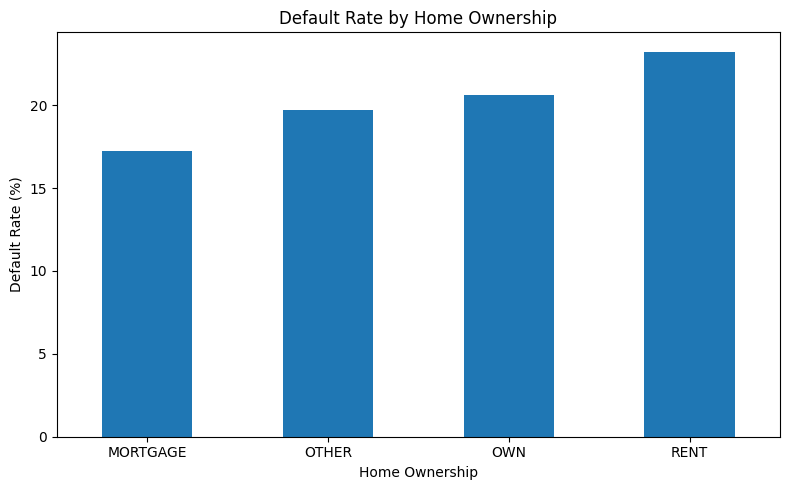

In [94]:
home_default["default_rate_%"].sort_values().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Default Rate by Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Lets analysis combined FICO and DTI**
  Lets create a risk matrix

In [95]:
fico_dti_risk = pd.pivot_table(
    df_clean,
    values="Default",
    index="fico_group",
    columns="dti_group",
    aggfunc="mean"
) * 100

fico_dti_risk.round(2)

dti_group,<10,10-20,20-30,30-40,40+
fico_group,,,,,
below 650,32.93,34.95,23.91,NaN,NaN
650-699,17.65,21.29,26.96,32.98,35.56
700-749,12.43,13.58,17.78,23.48,25.04
750+,8.15,7.62,10.61,14.96,16.45


**Lets visualize this as heatmap**

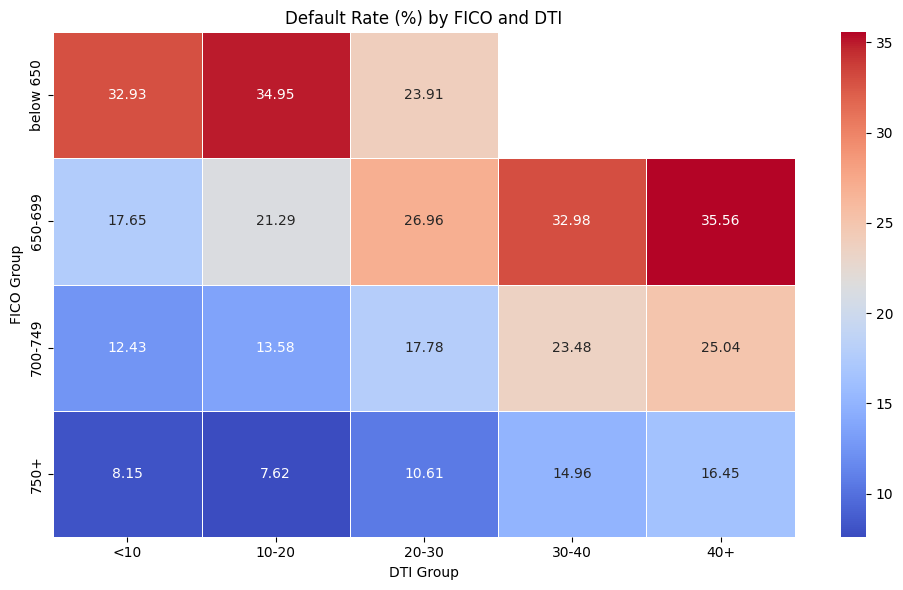

In [103]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    fico_dti_risk.round(2),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Default Rate (%) by FICO and DTI")
plt.xlabel("DTI Group")
plt.ylabel("FICO Group")
plt.tight_layout()
plt.show()

**Now analysis Default with Time**

In [108]:
# df_clean["issue_year"] = df["issue_date"].dt.year
df_clean["issue_year"] = df_clean["issue_date"].dt.year
df_clean[["issue_date", "issue_year"]].head()

,issue_date,issue_year
0,2015-12-01,2015
1,2015-12-01,2015
2,2015-12-01,2015
3,2015-12-01,2015
4,2015-12-01,2015


**Lets make a yearly portfolio performance**

In [109]:
yearly_default = (
    df_clean.groupby("issue_year")["Default"].agg(["count", "mean"])
)

yearly_default["default_rate_%"] = (
    yearly_default["mean"] * 100
).round(2)

yearly_default

,count,mean,default_rate_%
issue_year,,,
2007,599,0.263773,26.38
2008,2393,0.207271,20.73
2009,5281,0.136906,13.69
2010,12537,0.140145,14.01
2011,21721,0.151789,15.18
2012,53367,0.161973,16.20
2013,134804,0.155960,15.60
2014,223102,0.184494,18.45
2015,375543,0.201846,20.18


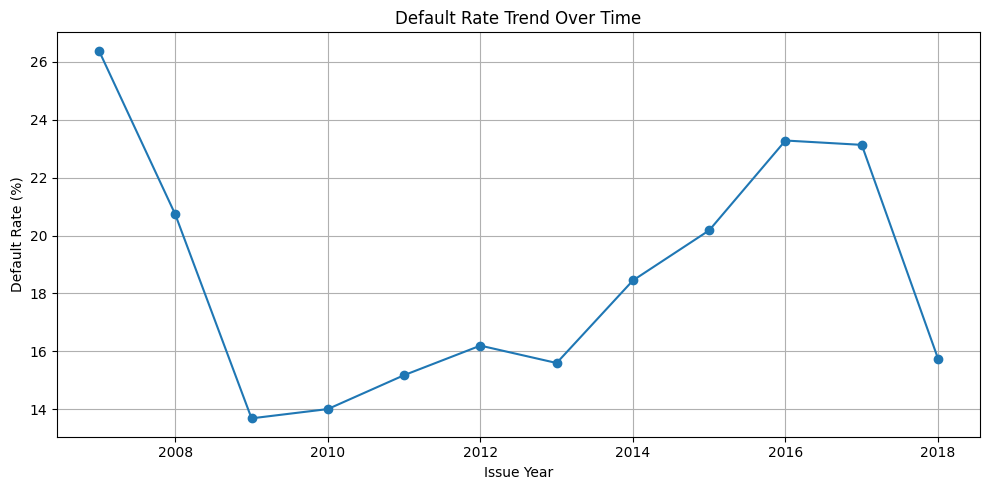

In [116]:
yearly_default["default_rate_%"].plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Default Rate Trend Over Time")
plt.xlabel("Issue Year")
plt.ylabel("Default Rate (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

**lets Calculate annual loan volume and exposure**

In [115]:
yearly_portfolio = (
    df_clean
    .groupby("issue_year")
    .agg(
        loan_count=("id", "count"),
        total_loan_amount=("loan_amnt", "sum"),
        avg_loan_amount=("loan_amnt", "mean"),
        default_rate=("Default", "mean")
    )
)

yearly_portfolio["default_rate_%"] = (
    yearly_portfolio["default_rate"] * 100
).round(2)

yearly_portfolio["total_loan_amount_($B)"] = (
    yearly_portfolio["total_loan_amount"] / 100000000
).round(2)

yearly_portfolio["avg_loan_amount"] = (
    yearly_portfolio["avg_loan_amount"]
).round(2)

yearly_portfolio

,loan_count,total_loan_amount,avg_loan_amount,default_rate,default_rate_%,total_loan_amount_($B)
issue_year,,,,,,
2007,599,4952275,8267.57,0.263773,26.38,0.05
2008,2393,21119250,8825.43,0.207271,20.73,0.21
2009,5281,51928250,9833.03,0.136906,13.69,0.52
2010,12537,131992550,10528.24,0.140145,14.01,1.32
2011,21721,261683825,12047.50,0.151789,15.18,2.62
2012,53367,718411025,13461.71,0.161973,16.20,7.18
2013,134804,1982613000,14707.38,0.155960,15.60,19.83
2014,223102,3253477500,14582.91,0.184494,18.45,32.53
2015,375543,5498542450,14641.58,0.201846,20.18,54.99


In [117]:
total_loans = len(df_clean)

total_exposure = df_clean["loan_amnt"].sum()

overall_default_rate = df_clean["Default"].mean() * 100

avg_loan = df_clean["loan_amnt"].mean()

print("Total Loans:", f"{total_loans:,}")
print("Total Loan Exposure: $", f"{total_exposure/1_000_000_000:.2f}", "B")
print("Overall Default Rate:", f"{overall_default_rate:.2f}%")
print("Average Loan Amount: $", f"{avg_loan:,.2f}")

Total Loans: 1,347,681
Total Loan Exposure: $ 19.42 B
Overall Default Rate: 19.98%
Average Loan Amount: $ 14,408.23


**Defaulted loan analysis**

In [118]:
defaulted_loans = df_clean[df_clean["Default"] == 1]

defaulted_count = len(defaulted_loans)

defaulted_exposure = defaulted_loans["loan_amnt"].sum()

defaulted_avg_loan = defaulted_loans["loan_amnt"].mean()

total_exposure = df_clean["loan_amnt"].sum()

defaulted_exposure_pct = (
    defaulted_exposure / total_exposure
) * 100

print("Defaulted Loans:", f"{defaulted_count:,}")
print("Defaulted Exposure: $", f"{defaulted_exposure/1_000_000_000:.2f} B")
print("Average Defaulted Loan: $", f"{defaulted_avg_loan:,.2f}")
print("Exposure in Defaulted Loans:", f"{defaulted_exposure_pct:.2f}%")

Defaulted Loans: 269,249
Defaulted Exposure: $ 4.19 B
Average Defaulted Loan: $ 15,547.02
Exposure in Defaulted Loans: 21.56%


**Lets create the Final Risk Segments**

In [119]:
def risk_category(row):
    if row["fico_n"] >= 750 and row["dti_n"] < 20:
        return "Low Risk"
    elif row["fico_n"] < 650 or row["dti_n"] >= 40:
        return "High Risk"
    else:
        return "Medium Risk"

df_clean["risk_category"] = df_clean.apply(
    risk_category,
    axis=1
)

risk_summary = (
    df_clean
    .groupby("risk_category")["Default"]
    .agg(["count", "mean"])
)

risk_summary["default_rate_%"] = (
    risk_summary["mean"] * 100
).round(2)

risk_summary.sort_values(
    "default_rate_%",
    ascending=False
)

,count,mean,default_rate_%
risk_category,,,
High Risk,7001,0.307527,30.75
Medium Risk,1264175,0.206533,20.65
Low Risk,76505,0.078452,7.85


In [121]:
purpose_default.sort_values(
    "default_rate_%",
    ascending=False
).head(5)

,count,mean,default_rate_%
purpose,,,
small_business,15575,0.298555,29.86
renewable_energy,936,0.237179,23.72
moving,9520,0.234139,23.41
house,7294,0.219084,21.91
medical,15606,0.218442,21.84


**Lets create a Final Credit Risk Summary**

In [120]:
print("========== CREDIT RISK SUMMARY ==========")

print(f"Total Loans: {len(df_clean):,}")

print(
    f"Total Loan Exposure: "
    f"${df_clean['loan_amnt'].sum()/1_000_000_000:.2f} B"
)

print(
    f"Overall Default Rate: "
    f"{df_clean['Default'].mean()*100:.2f}%"
)

print(
    f"Average Loan Amount: "
    f"${df_clean['loan_amnt'].mean():,.2f}"
)

print(
    f"Average FICO Score: "
    f"{df_clean['fico_n'].mean():.0f}"
)

print(
    f"Average DTI: "
    f"{df_clean['dti_n'].mean():.2f}"
)

========== CREDIT RISK SUMMARY ==========
Total Loans: 1,347,681
Total Loan Exposure: $19.42 B
Overall Default Rate: 19.98%
Average Loan Amount: $14,408.23
Average FICO Score: 698
Average DTI: 18.27


In [122]:
df_clean.to_csv("../data/cleaned_loan_data.csv", index=False)

In [123]:
df_clean.head()

,id,issue_d,revenue,dti_n,loan_amnt,fico_n,experience_c,emp_length,purpose,home_ownership_n,addr_state,zip_code,Default,issue_date,issue_year,issue_month,fico_group,dti_group,loan_group,risk_category
0,68407277,Dec-2015,55000.0,5.91,3600,677.0,1,10+ years,debt_consolidation,MORTGAGE,PA,190xx,0,2015-12-01,2015,12,650-699,<10,<5k,Medium Risk
1,68355089,Dec-2015,65000.0,16.06,24700,717.0,1,10+ years,small_business,MORTGAGE,SD,577xx,0,2015-12-01,2015,12,700-749,10-20,20k-30k,Medium Risk
2,68341763,Dec-2015,71000.0,13.85,20000,697.0,1,10+ years,home_improvement,MORTGAGE,IL,605xx,0,2015-12-01,2015,12,650-699,10-20,20k-30k,Medium Risk
3,68476807,Dec-2015,104433.0,25.37,10400,697.0,1,3 years,major_purchase,MORTGAGE,PA,174xx,0,2015-12-01,2015,12,650-699,20-30,10k-20k,Medium Risk
4,68426831,Dec-2015,34000.0,10.20,11950,692.0,1,4 years,debt_consolidation,RENT,GA,300xx,0,2015-12-01,2015,12,650-699,10-20,10k-20k,Medium Risk
